<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fpranathi_kolla/weeks/week_02/02_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [1]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "content/butteflai/"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/content/butteflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_6238/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_6238/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


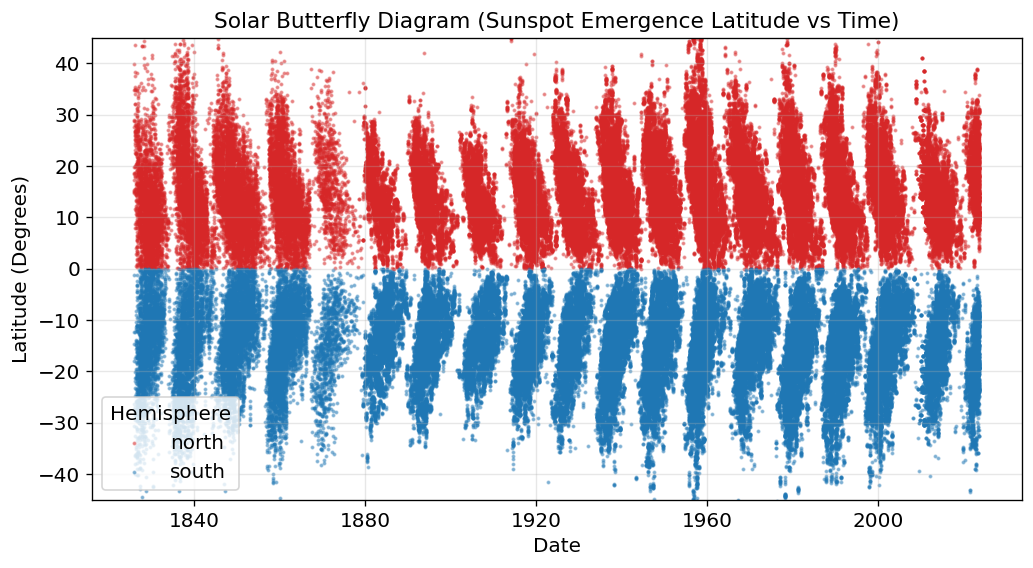

In [3]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (Degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


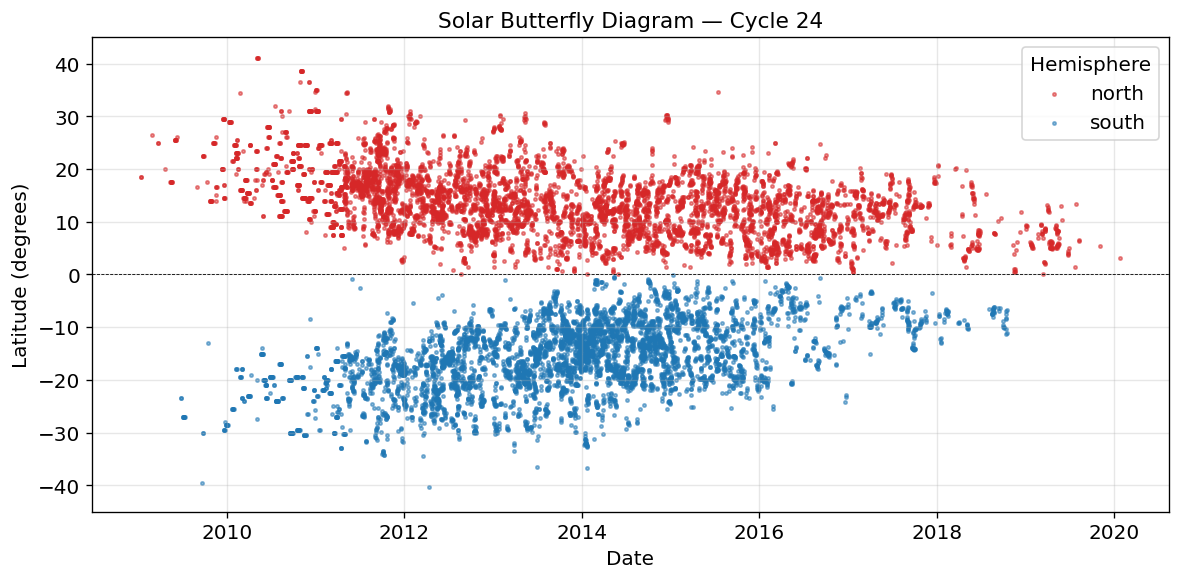

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [4]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_6238/1504047978.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


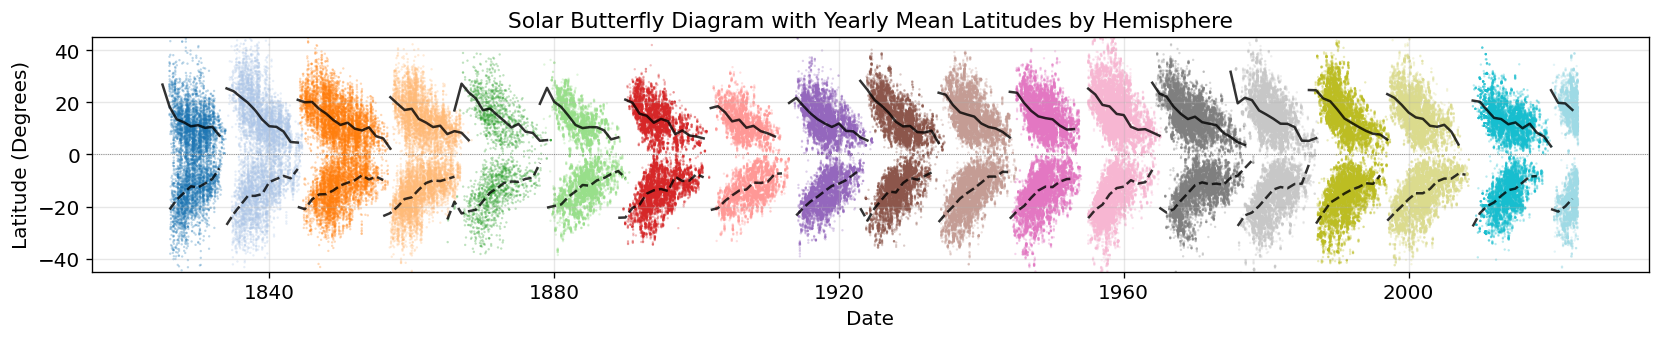

In [5]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (Degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

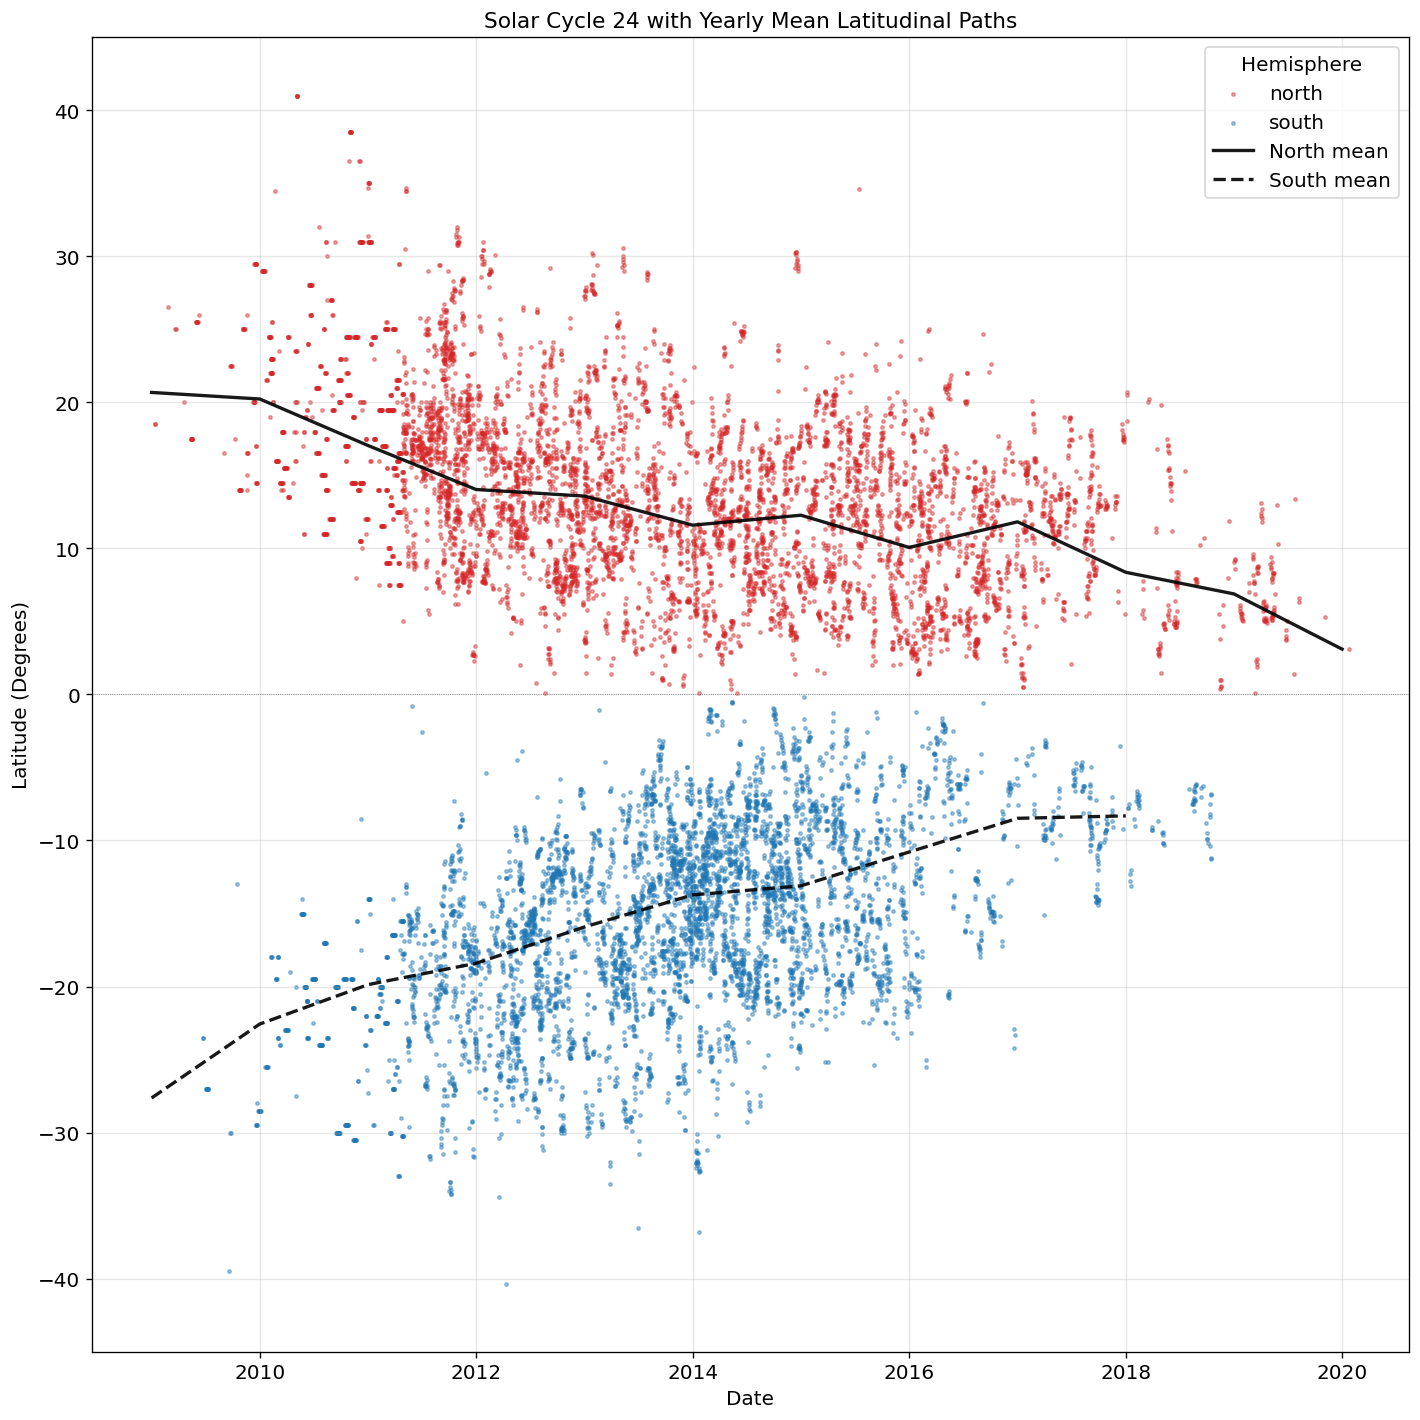

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [6]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (Degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


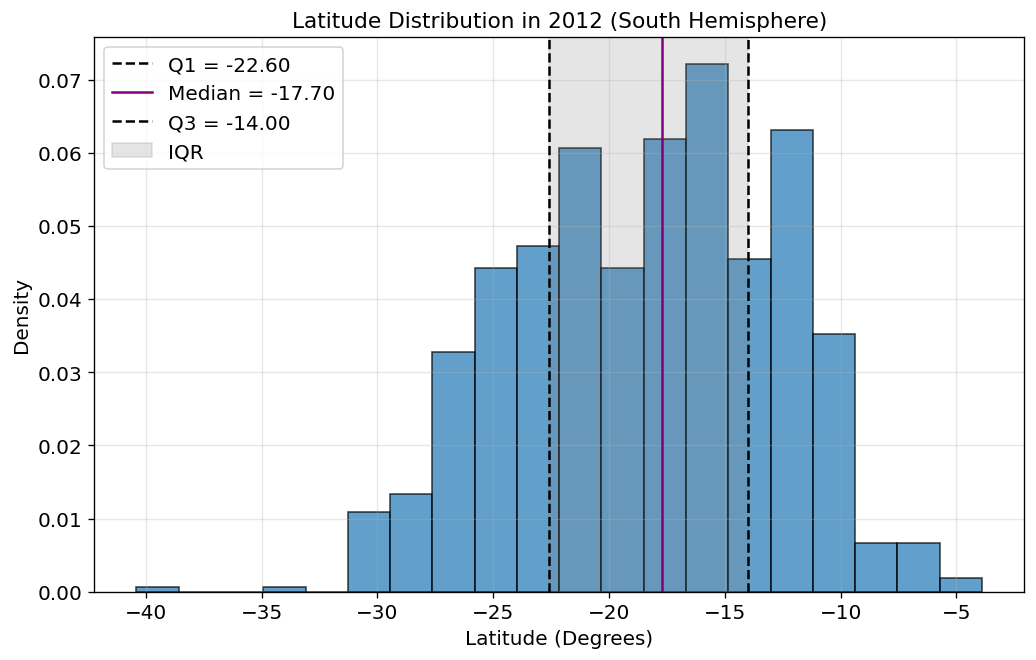

In [15]:
# Put your code for Task 6 here
year = 2012
hemi = "south"

sub = df[(df["date"].dt.year == year) & (df["hemisphere"] == hemi)].copy()

vals = sub["latitude"].dropna()
q1 = vals.quantile(0.25)
med = vals.quantile(0.50)
q3 = vals.quantile(0.75)

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(vals, bins=20, density=True, alpha=0.7, color=colors[hemi], edgecolor="black")

ax.axvline(q1, color="black", linestyle="--", label=f"Q1 = {q1:.2f}")
ax.axvline(med, color="purple", linestyle="-", label=f"Median = {med:.2f}")
ax.axvline(q3, color="black", linestyle="--", label=f"Q3 = {q3:.2f}")
ax.axvspan(q1, q3, color="gray", alpha=0.2, label="IQR")

ax.set_title(f"Latitude Distribution in {year} ({hemi.capitalize()} Hemisphere)")
ax.set_xlabel("Latitude (Degrees)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

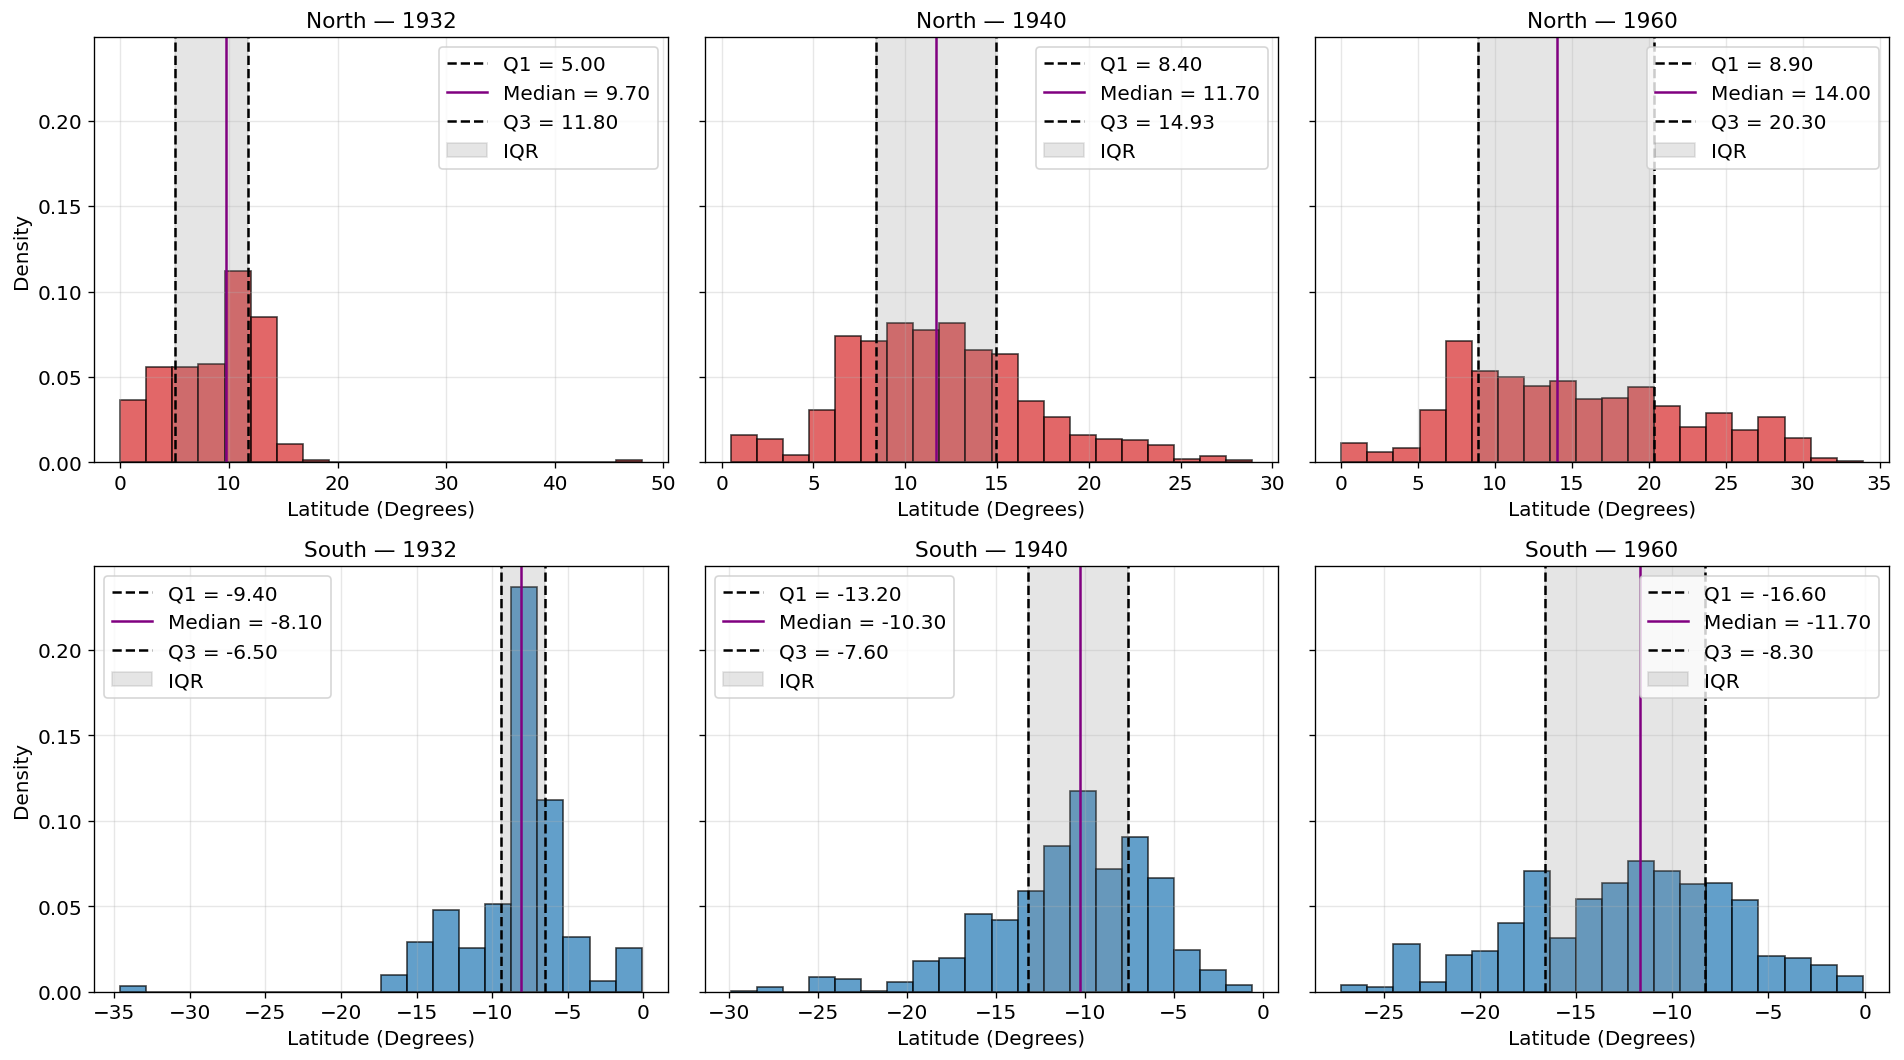

In [11]:
## Once I wrote the initial code above, I utilized Gemini to run this on different years and hemispheres. The code for that is shown here.

years = [1932, 1940, 1960]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

for j, hemi in enumerate(["north", "south"]):
    for i, year in enumerate(years):
        ax = axes[j, i]
        sub = df[(df["date"].dt.year == year) & (df["hemisphere"] == hemi)].copy()
        vals = sub["latitude"].dropna()

        q1 = vals.quantile(0.25)
        med = vals.quantile(0.50)
        q3 = vals.quantile(0.75)

        ax.hist(vals, bins=20, density=True, alpha=0.7,
                color=colors[hemi], edgecolor="black")

        ax.axvline(q1, color="black", linestyle="--", label=f"Q1 = {q1:.2f}")
        ax.axvline(med, color="purple", linestyle="-", label=f"Median = {med:.2f}")
        ax.axvline(q3, color="black", linestyle="--", label=f"Q3 = {q3:.2f}")
        ax.axvspan(q1, q3, color="gray", alpha=0.2, label="IQR")

        ax.set_title(f"{hemi.capitalize()} — {year}")
        ax.set_xlabel("Latitude (Degrees)")
        if i == 0:
            ax.set_ylabel("Density")
        ax.legend()

plt.tight_layout()
plt.show()

*What shape does the distribution have? Is it symmetric?*
The latitude distributions usually have one main peak, but they are not perfectly symmetric. Instead of looking like clean bell curves, many of them are a little lopsided, with one side stretching out more than the other and a few outliers showing up as well. So overall, the distributions are best described as single-peaked but somewhat skewed rather than fully symmetric.


*Try switching to the other hemisphere and try different years — does the shape change?*

The shape also changes when you switch between hemispheres and years. Some years have a tighter, more concentrated distribution, while others are much broader and more spread out. The north and south look similar in the sense that both show a main activity belt, but they are mirrored across the equator and do not match exactly in width, center, or skewness. This suggests that the sunspot emergence pattern is not fixed, but shifts over time as the solar cycle evolves.


## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


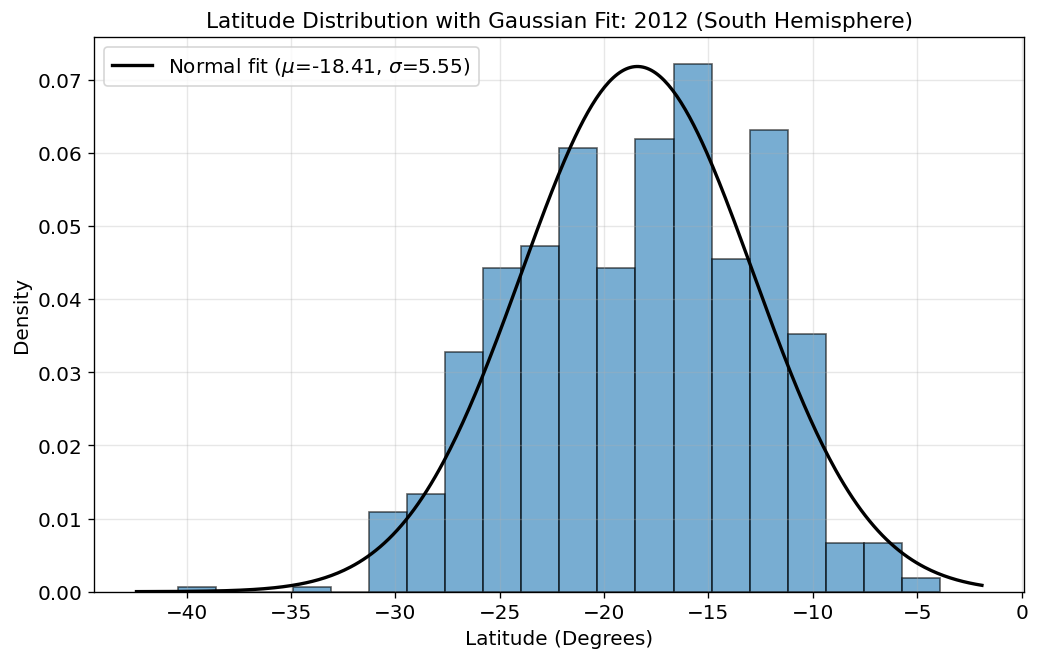

In [16]:
# Put your code for Task 7 here
from scipy.stats import norm
import numpy as np

year = 2012
hemi = "south"

sub = df[(df["date"].dt.year == year) & (df["hemisphere"] == hemi)].copy()
vals = sub["latitude"].dropna().to_numpy()

mu, sigma = norm.fit(vals)

x = np.linspace(vals.min() - 2, vals.max() + 2, 400)
pdf = norm.pdf(x, mu, sigma)

q1 = np.quantile(vals, 0.25)
med = np.quantile(vals, 0.50)
q3 = np.quantile(vals, 0.75)

fig, ax = plt.subplots(figsize=(10,6))
ax.hist(vals, bins=20, density=True, alpha=0.6, color=colors[hemi], edgecolor="black")
ax.plot(x, pdf, color="black", linewidth=2, label=f"Normal fit ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})")

# ax.axvline(q1, color="gray", linestyle="--")
# ax.axvline(med, color="purple", linestyle="-")
# ax.axvline(q3, color="gray", linestyle="--")
# ax.axvspan(q1, q3, color="gray", alpha=0.15)

ax.set_title(f"Latitude Distribution with Gaussian Fit: {year} ({hemi.capitalize()} Hemisphere)")
ax.set_xlabel("Latitude (Degrees)")
ax.set_ylabel("Density")
ax.legend()
plt.show()

*Does it fit well? Where does it agree with the data and where does it fail?*
In this case, the Gaussian fits the distribution reasonably well overall, especially in the center where most of the sunspot emergence latitudes are concentrated. The peak of the curve lines up with the main body of the histogram, so it does a good job capturing the typical latitude range for that year and hemisphere. Where it starts to fail is in the tails, since the real data are a bit uneven and include a few more extreme values than the smooth Gaussian would predict. So it works well as a simple summary, but it does not capture every detail of the empirical shape.

*The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?*

Physically, μ represents the average or central latitude where sunspots are emerging in that hemisphere during that year. In this case, μ = -18.41 degrees means the typical emergence latitude is around 18 degrees south. The parameter σ represents the spread of the activity belt around that central latitude. Here, σ = 5.55 degrees tells us how wide the sunspot emergence region is, or how much variation/ deviation there is around the average latitude.

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


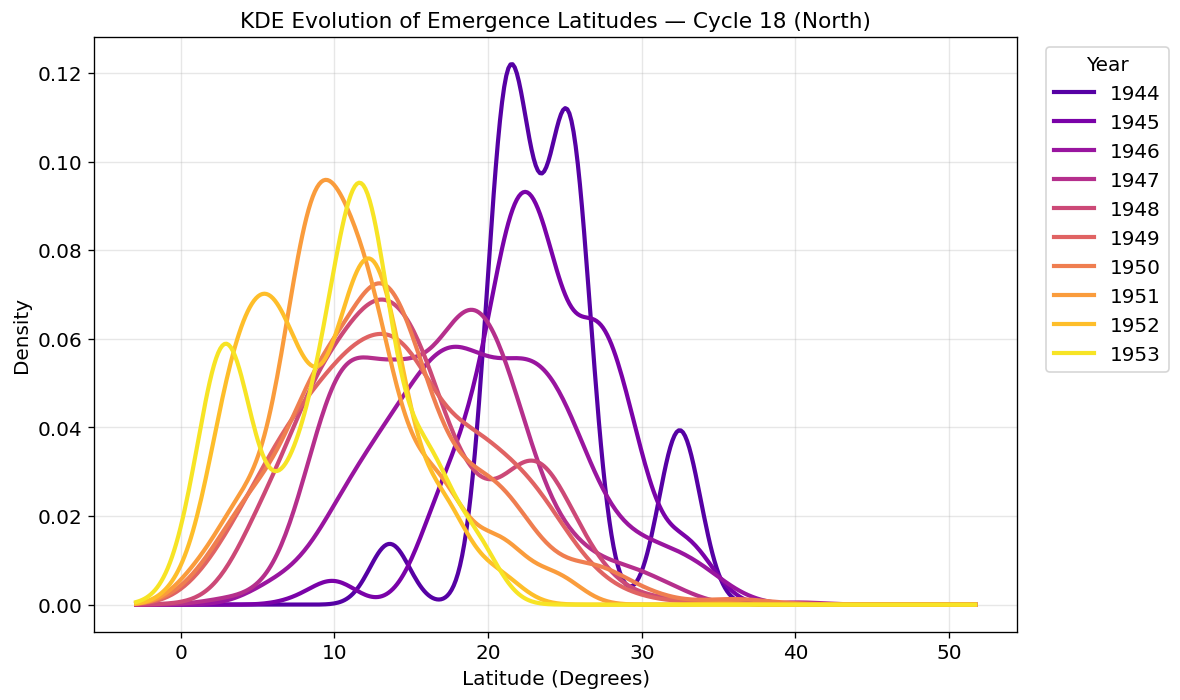

In [18]:
# Put your code for Task 8 here
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

cycle_num = 18
hemi = "north"
bw = 0.3

sub = df[(df["CYCLE"] == cycle_num) & (df["hemisphere"] == hemi)].copy()
sub["year"] = sub["date"].dt.year

years = sorted(sub["year"].dropna().unique())
x = np.linspace(sub["latitude"].min() - 3, sub["latitude"].max() + 3, 400)

fig, ax = plt.subplots(figsize=(10,6))

color_vals = np.linspace(0.15, 0.95, len(years))
colors_kde = plt.cm.plasma(color_vals)

for c, y in zip(colors_kde, years):
    vals = sub.loc[sub["year"] == y, "latitude"].dropna().to_numpy()
    if len(vals) < 5:
        continue
    kde = gaussian_kde(vals, bw_method=bw)
    ax.plot(x, kde(x), color=c, linewidth=2.5, label=str(y))

ax.set_title(f"KDE Evolution of Emergence Latitudes — Cycle {cycle_num} ({hemi.capitalize()})")
ax.set_xlabel("Latitude (Degrees)")
ax.set_ylabel("Density")
ax.legend(title="Year", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

*Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?*

Yes, the distributions do shift toward the equator as the cycle progresses. In the early years, the KDE peaks are centered at higher latitudes, around the low-to-mid 20s, while in later years they move downward toward lower latitudes, closer to about 10 degrees. That is exactly the equatorward drift expected from Spörer’s Law as aformentioned!

The width changes too. Earlier in the cycle, some distributions are broader and sometimes even multi-peaked, while later in the cycle many of them become more concentrated at lower latitudes. So the region of activity is not just moving equatorward — its spread is also evolving over time.